<a href="https://colab.research.google.com/github/dsc-courses/cosmos-ml-cluster-2026/blob/main/lectures/lec13/lec13_mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [ ]:
type(X)

pandas.core.frame.DataFrame

In [ ]:
# convert to np arrays so that data "plays nice" with libraries
X = np.array(X)
y = np.array(y)

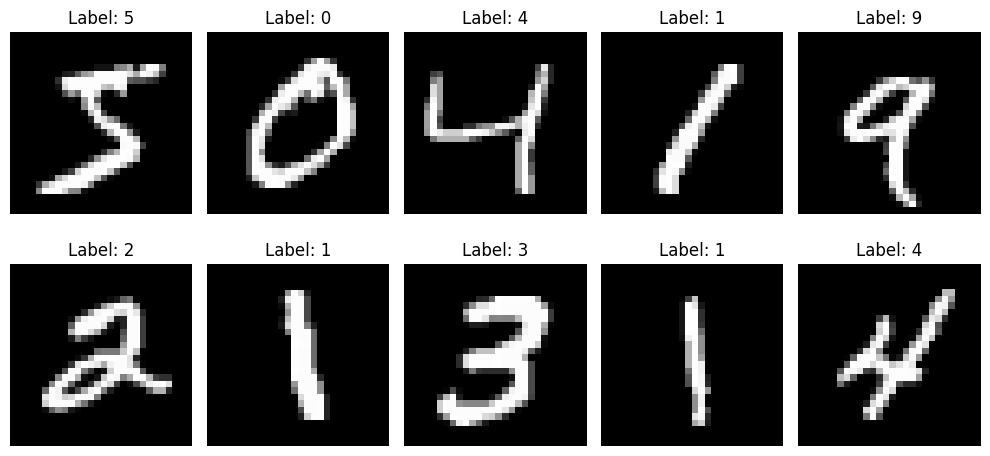

In [ ]:
# Visualize a few images from the dataset
def visualize_images(X, y):
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(X[i, :].reshape(28, 28), cmap='gray')
        ax.set_title(f"Label: {y[i]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_images(X, y)

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale the data (important for neural networks)
# when working with images, it is common to scale the
# data by dividing everything by the max value (255)
# so that data is in [0, 1]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# Initialize and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64,64,32), max_iter=50)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 64, 32), max_iter=50)

In [ ]:
# Evaluate the model
y_pred = mlp.predict(X_test)
acc = mlp.score(X_test, y_test)
print("Accuracy:", acc)
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9718571428571429
Confusion matrix:
 [[1315    1    1    0    1    3   12    2    6    2]
 [   0 1577    5    2    1    1    2    6    5    1]
 [   3    3 1334    6    5    2    6    5   14    2]
 [   2    3   11 1391    0    8    2    6    5    5]
 [   1    2    1    2 1253    0    6    4    3   23]
 [   1    3    0   15    2 1235    7    0    7    3]
 [   2    1    2    0    9    5 1370    2    4    1]
 [   1    2   16    0    6    2    0 1460    2   14]
 [   4    5    8   10    1    8    5    6 1300   10]
 [   7    3    2    2   17    3    0    8    7 1371]]


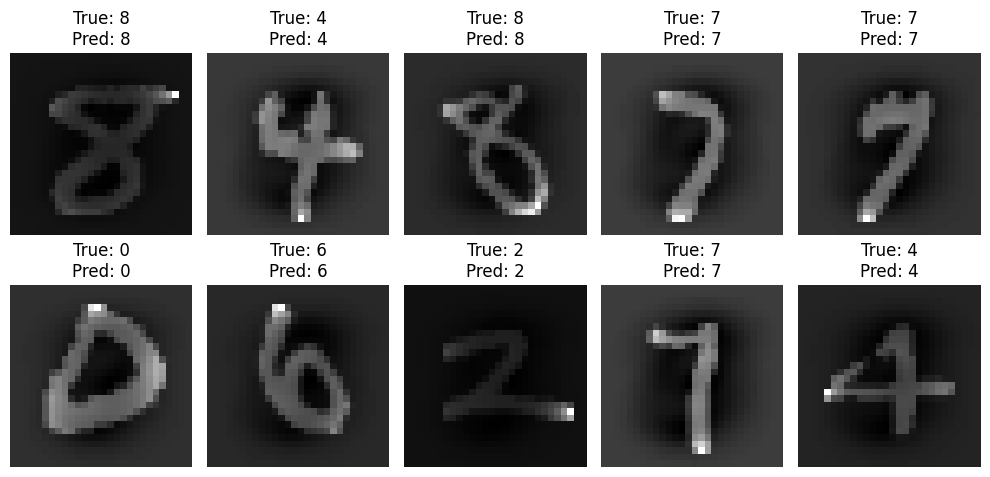

In [ ]:
# Visualize some of the predictions
def visualize_predictions(X, y_true, y_pred):
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(X[i].reshape(28, 28), cmap='gray')
        ax.set_title(f"True: {y_true[i]}\nPred: {y_pred[i]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(X_test, y_test, y_pred)

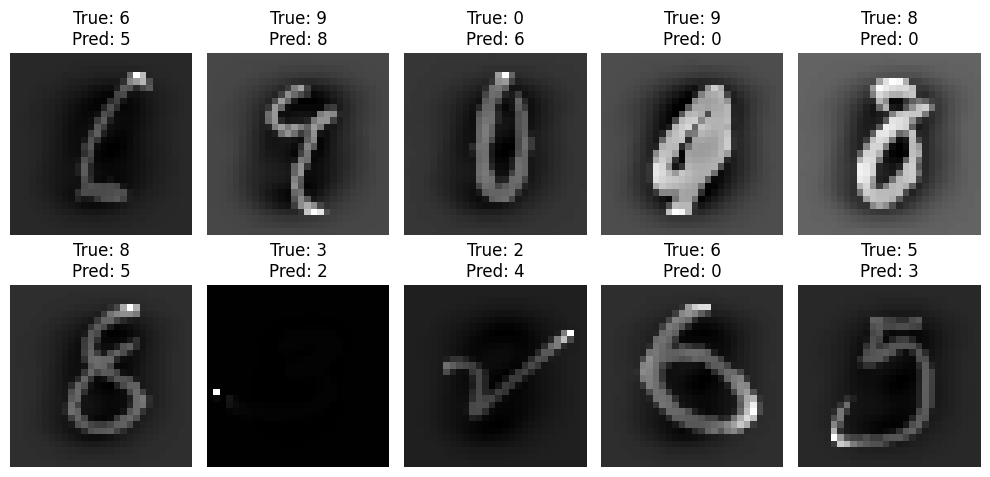

In [ ]:
incorrect_indices = np.where(y_test != y_pred)[0]
X_incorrect = X_test[incorrect_indices]
y_true_incorrect = y_test[incorrect_indices]
y_pred_incorrect = y_pred[incorrect_indices]

visualize_predictions(X_incorrect, y_true_incorrect, y_pred_incorrect)